In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [3]:
# Load the dataset from a CSV file
def load_data(input_path):
    """
    Loads a dataset from the given CSV file path and returns a pandas DataFrame.
    Args:
        input_path (str): Path to the CSV file.
    Returns:
        pd.DataFrame: Loaded data.
    """
    df = pd.read_csv(input_path)
    return df

In [6]:
# Preprocess the data: separate features, encode categoricals, impute missing values, and scale
def preprocess_data(df):
    """
    Preprocesses the input DataFrame by separating features, encoding categorical variables, imputing missing values, and scaling features.
    Args:
        df (pd.DataFrame): Input data.
    Returns:
        X_scaled (np.ndarray): Scaled feature matrix.
        y (np.ndarray): Target variable array.
        encoder (OneHotEncoder): Fitted encoder for categorical features.
        categorical_cols (list): List of categorical feature names.
        numerical_cols (list): List of numerical feature names.
        features (list): List of all feature names.
    """
    features = [col for col in df.columns if col != 'default_flag']
    categorical_cols = df[features].select_dtypes(include=['object']).columns.tolist()
    numerical_cols = df[features].select_dtypes(exclude=['object']).columns.tolist()
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat = encoder.fit_transform(df[categorical_cols])
    X_num = df[numerical_cols].values
    X_all = np.hstack([X_num, X_cat])
    imputer = SimpleImputer(strategy='mean')
    X_all_imputed = imputer.fit_transform(X_all)
    X_scaled = StandardScaler().fit_transform(X_all_imputed)
    y = df['default_flag'].values
    return X_scaled, y, encoder, categorical_cols, numerical_cols, features

In [7]:
# Perform PCA for 2 components and plot the 2D visualization
def plot_pca_2d(X_scaled, y):
    """
    Performs PCA with 2 components and plots a 2D scatter plot of the transformed data, colored by the target variable.
    Args:
        X_scaled (np.ndarray): Scaled feature matrix.
        y (np.ndarray): Target variable array.
    Returns:
        PCA: Fitted PCA object with 2 components.
    """
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, cmap='viridis', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('2D PCA Visualization')
    plt.colorbar(scatter, label='Default Flag')
    plt.tight_layout()
    plt.show()
    return pca_2d

In [19]:
# Perform PCA for 3 components and plot the 3D visualization with distinct colors
def plot_pca_3d(X_scaled, y):
    """
    Performs PCA with 3 components and plots a 3D scatter plot of the transformed data, colored by the target variable with distinct colors.
    Args:
        X_scaled (np.ndarray): Scaled feature matrix.
        y (np.ndarray): Target variable array.
    Returns:
        PCA: Fitted PCA object with 3 components.
    """
    from matplotlib.colors import ListedColormap
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    # Define distinct colors for each class
    unique_classes = np.unique(y)
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    cmap = ListedColormap(colors[:len(unique_classes)])
    scatter = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=y, cmap=cmap, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.title('3D PCA Visualization')
    # Create a legend for each class
    handles = [plt.Line2D([0],[0], marker='o', color='w', label=str(cls), markerfacecolor=colors[i], markersize=10) for i, cls in enumerate(unique_classes)]
    ax.legend(handles=handles, title='Default Flag', loc='best')
    plt.tight_layout()
    plt.show()
    return pca_3d

In [9]:
# Print top features and their weights for each PCA 2D component
def print_pca2_feature_weights(pca, encoder, categorical_cols, numerical_cols, n_top=10):
    """
    Prints the top features and their weights for each PCA 2D component.
    Args:
        pca (PCA): Fitted PCA object with 2 components.
        encoder (OneHotEncoder): Fitted encoder for categorical features.
        categorical_cols (list): List of categorical feature names.
        numerical_cols (list): List of numerical feature names.
        n_top (int): Number of top features to display per component.
    """
    cat_feature_names = encoder.get_feature_names_out(categorical_cols)
    all_feature_names = numerical_cols + list(cat_feature_names)
    for i, comp in enumerate(pca.components_):
        print(f'\nPCA 2D Component {i+1}:')
        print(f'  Number of features: {len(comp)}')
        sorted_idx = np.argsort(np.abs(comp))[::-1]
        for idx in sorted_idx[:n_top]:
            print(f'{all_feature_names[idx]}: {comp[idx]:.4f}')

In [10]:
# Print top features and their weights for each PCA 3D component
def print_pca3_feature_weights(pca, encoder, categorical_cols, numerical_cols, n_top=10):
    """
    Prints the top features and their weights for each PCA 3D component.
    Args:
        pca (PCA): Fitted PCA object with 3 components.
        encoder (OneHotEncoder): Fitted encoder for categorical features.
        categorical_cols (list): List of categorical feature names.
        numerical_cols (list): List of numerical feature names.
        n_top (int): Number of top features to display per component.
    """
    cat_feature_names = encoder.get_feature_names_out(categorical_cols)
    all_feature_names = numerical_cols + list(cat_feature_names)
    print(f'Number of components in PCA 3D: {pca.n_components_}')
    for i, comp in enumerate(pca.components_):
        print(f'\nPCA 3D Component {i+1}:')
        print(f'  Number of features: {len(comp)}')
        sorted_idx = np.argsort(np.abs(comp))[::-1]
        for idx in sorted_idx[:n_top]:
            print(f'{all_feature_names[idx]}: {comp[idx]:.4f}')

In [11]:
# Interactive scatter plot for any two selected features
def plot_feature_scatter(df, feature_names, y):
    """
    Creates an interactive scatter plot for any two selected features using ipywidgets. The points are colored by the target variable.
    Args:
        df (pd.DataFrame): Input data.
        feature_names (list): List of feature names to select from.
        y (np.ndarray): Target variable array.
    """
    feature1 = widgets.Dropdown(options=feature_names, description='Feature 1:')
    feature2 = widgets.Dropdown(options=feature_names, description='Feature 2:')
    button = widgets.Button(description="Plot")
    output = widgets.Output()
    def on_button_clicked(b):
        with output:
            output.clear_output()
            plt.figure(figsize=(8,6))
            plt.scatter(df[feature1.value], df[feature2.value], c=y, cmap='viridis', alpha=0.7)
            plt.xlabel(feature1.value)
            plt.ylabel(feature2.value)
            plt.title(f'Scatter Plot: {feature1.value} vs {feature2.value}')
            plt.colorbar(label='Default Flag')
            plt.tight_layout()
            plt.show()
    button.on_click(on_button_clicked)
    display(widgets.VBox([feature1, feature2, button, output]))

In [ ]:
# Main function to run all steps: load, preprocess, PCA, print weights, and interactive plot
def run():
    """
    Orchestrates the full workflow: loads data, preprocesses it, performs PCA and visualizations, prints feature weights, enables interactive feature comparison, and saves PCA data.
    """
    input_path = 'C:/Users/PJ989UA/amts/amts/machine_learning/data/outputs/00_data_preparation/train_df.csv'
    df = load_data(input_path)
    X_scaled, y, encoder, categorical_cols, numerical_cols, features = preprocess_data(df)
    # 2D PCA
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    print("Explained variance ratio (2D):", pca_2d.explained_variance_ratio_)
    # Save 2D PCA data
    pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
    pca_2d_df.to_csv('pca_2d_output.csv', index=False)
    plot_pca_2d(X_scaled, y)
    # 3D PCA
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    print("Explained variance ratio (3D):", pca_3d.explained_variance_ratio_)
    # Save 3D PCA data
    pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
    pca_3d_df.to_csv('pca_3d_output.csv', index=False)
    plot_pca_3d(X_scaled, y)
    print('Top features for each PCA 2D component:')
    print_pca2_feature_weights(pca_2d, encoder, categorical_cols, numerical_cols)
    print('Top features for each PCA 3D component:')
    print_pca3_feature_weights(pca_3d, encoder, categorical_cols, numerical_cols)
    print('Select any two features to plot:')
    plot_feature_scatter(df, features, y)

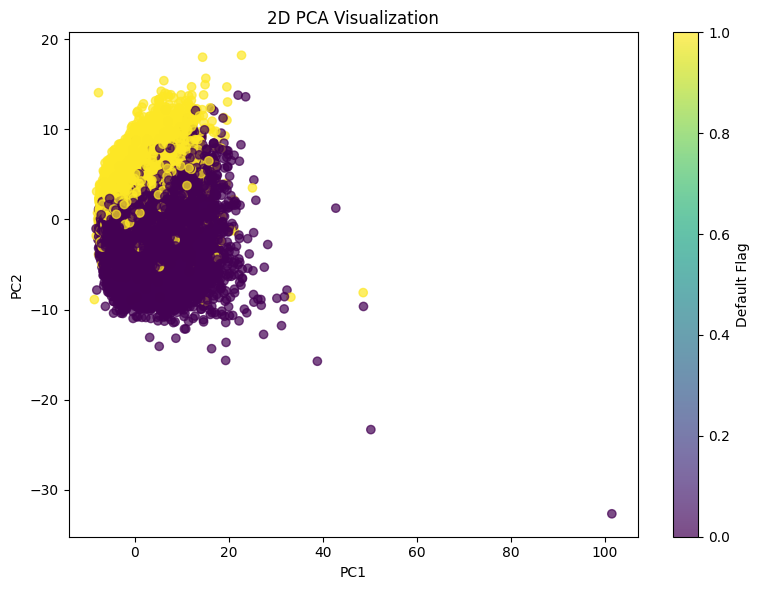

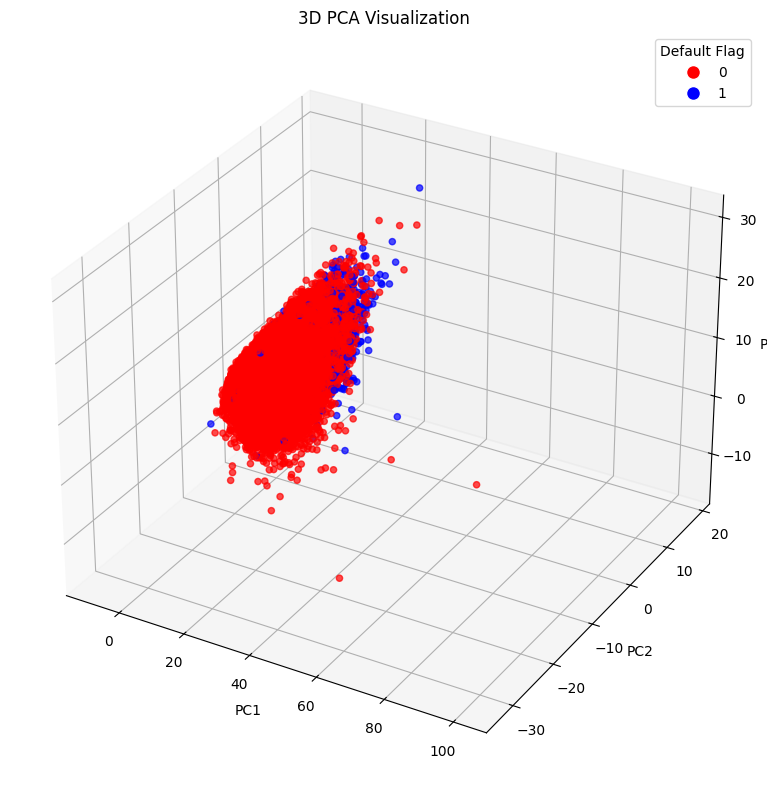

Explained variance ratio: [0.0544379  0.03458343]
Explained variance ratio: [0.0544379  0.03458343 0.03287152]
Top features for each PCA 2D component:

PCA 2D Component 1:
  Number of features: 211
funded_amnt: 0.2247
loan_amnt: 0.2247
funded_amnt_inv: 0.2246
total_pymnt: 0.2158
total_pymnt_inv: 0.2158
installment: 0.2095
total_rec_prncp: 0.2078
total_bc_limit: 0.1902
num_sats: 0.1843
open_acc: 0.1842

PCA 2D Component 2:
  Number of features: 211
int_rate: 0.2455
last_fico_range_high: -0.2430
fico_range_high: -0.2213
fico_range_low: -0.2213
loan_status_Fully Paid: -0.2197
loan_status_Charged Off: 0.2190
last_fico_range_low: -0.2018
grade_A: -0.1942
num_actv_rev_tl: 0.1707
num_rev_tl_bal_gt_0: 0.1694
Top features for each PCA 3D component:
Number of components in PCA 3D: 3

PCA 3D Component 1:
  Number of features: 211
funded_amnt: 0.2247
loan_amnt: 0.2247
funded_amnt_inv: 0.2246
total_pymnt: 0.2158
total_pymnt_inv: 0.2158
installment: 0.2095
total_rec_prncp: 0.2078
total_bc_limit: 0.1

In [21]:
# Run the complete workflow
run()